In [1]:
# %%

import os
import wandb
import argparse
import itertools
import numpy as np
import jax
import jax.numpy as jnp
from jaxrl_m.common import CodeTimer
import logging
import envpool
logging.basicConfig(level=logging.CRITICAL)


def get_batch(i,batches):
    return  jax.tree.map(lambda x: x[i], batches)

def body(i,val):
    agent,batches = val
    return (agent.update_critics(get_batch(i,batches)),batches)

def str2bool(v):
    if isinstance(v, bool):
        return v
    if v.lower() in ('yes', 'true', 't', 'y', '1'):
        return True
    elif v.lower() in ('no', 'false', 'f', 'n', '0'):
        return False
    else:
        raise argparse.ArgumentTypeError('Boolean value expected.')
    

def none_or_str(value):
    if value == 'None':
        return None
    return value

# Set env variables
os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
os.environ['PYTHONHASHSEED'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

##############################
parser = argparse.ArgumentParser()

parser.add_argument('--seed',type=int,default=42) 

parser.add_argument('--algo_name', type=str, default='superppo', help='the name of the RL algorithm')
parser.add_argument('--project_name',type=str,default="single_exp") 

parser.add_argument('--env_name',type=str,default="Hopper-v5") 
parser.add_argument('--max_steps',type=int,default=30_000) 
parser.add_argument('--max_episode_steps',type=int,default=500) 
parser.add_argument('--num_rollouts',type=int,default=4) 
parser.add_argument('--gamma',type=float,default=0.99)
parser.add_argument('--healthy_reward',type=float,default=1.) 
parser.add_argument('--entropy_coeff',type=float,default=1.) 

parser.add_argument('--discount_actor',type=str2bool,default=True)
parser.add_argument('--min_target',type=str2bool,default=False)
parser.add_argument('--discount_entropy',type=str2bool,default=True) 
parser.add_argument('--on_policy_data',type=str2bool,default=False)
parser.add_argument('--adaptive_critics',type=str2bool,default=False) 
parser.add_argument('--num_critics',type=int,default=1)

parser.add_argument('--critic_lr',type=float,default=3e-4) 
parser.add_argument('--actor_lr',type=float,default=3e-4) 
parser.add_argument('--temp_lr',type=float,default=3e-4)
parser.add_argument('--use_layer_norm',type=str2bool,default=True)

parser.add_argument('--momentum',type=float,default=0.) 
parser.add_argument('--num_actor_updates',type=int,default=5) 
parser.add_argument('--clipping_ratio',type=float,default=0.1) 
parser.add_argument('--hidden_dims',type=int,default=64) 
parser.add_argument('--episode_based',type=str2bool,default=False) 
parser.add_argument('--tanh_squash_actions',type=str2bool,default=True) 


args = parser.parse_args(args=[])

from jaxrl_m.onsac_clean import *

hidden_dims = ()
NUM_UPDATES = 1000





import os
from functools import partial
import numpy as np
import jax
import tqdm
import gymnasium as gym


from jaxrl_m.wandb import setup_wandb, default_wandb_config, get_flag_dict
import wandb
from jaxrl_m.evaluation import supply_rng, evaluate, flatten, EpisodeMonitor
from jaxrl_m.dataset import ReplayBuffer,ActorReplayBuffer
from collections import deque
from jax import config
from jaxrl_m.utils import flatten_rollouts
from jaxrl_m.evaluate_critic import evaluate_many_critics
from jaxrl_m.rollout import rollout_policy2
from jax import config
config.update("jax_debug_nans", True)

eval_episodes=10
batch_size = 256
max_steps = args.max_steps
start_steps = 0
log_interval = 10000
n_grads = 0


### HalfCheetah does not have healthy_reward argument
if 'HalfCheetah' in args.env_name or 'Standup' in args.env_name:
    env = EpisodeMonitor(gym.make(args.env_name, max_episode_steps=args.max_episode_steps))
else:
    print(f'env_name: {args.env_name}, max_episode_steps: {args.max_episode_steps}, healthy_reward: {args.healthy_reward}')
    env = gym.make(args.env_name, max_episode_steps=args.max_episode_steps, healthy_reward=args.healthy_reward)

eval_env = EpisodeMonitor(gym.make(args.env_name,max_episode_steps=1000))


example_transition = dict(
    observations=env.observation_space.sample(),
    actions=env.action_space.sample(),
    rewards=0.0,
    masks=1.0,
    next_observations=env.observation_space.sample(),
    pre_actions = env.action_space.sample(),
    discounts=1.0,
    log_probs=0.,
)

buffer_size = args.num_rollouts*args.max_episode_steps if args.on_policy_data else 100_000
replay_buffer = ReplayBuffer.create(example_transition, size=int(buffer_size))
actor_buffer = ActorReplayBuffer.create(example_transition, size=int(args.num_rollouts*args.max_episode_steps))
test_buffer = ActorReplayBuffer.create(example_transition, size=int(args.num_rollouts*args.max_episode_steps))

args_dict = {

"seed": args.seed,
"observations":example_transition['observations'][None],
"actions":example_transition['actions'][None],
"max_steps":max_steps,
"discount":args.gamma,
"discount_actor":args.discount_actor,
"min_target":args.min_target,
"discount_entropy":args.discount_entropy,
"adaptive_critics":args.adaptive_critics,
"num_critics": args.num_critics,
"entropy_coeff":args.entropy_coeff,
"temp_lr":args.temp_lr,
"actor_lr":args.actor_lr,
"critic_lr":args.critic_lr,
"momentum":args.momentum,
"clipping_ratio":args.clipping_ratio,
"num_actor_updates":args.num_actor_updates,
"critic_hidden_dims":(args.hidden_dims,args.hidden_dims),
"actor_hidden_dims":(),
"use_layer_norm": args.use_layer_norm,
"state_dependent_std":False,
"tanh_squash_distribution":False,
"tanh_squash_actions":False,
"use_bias":False,

}
agent = create_learner(**args_dict)

##############




exploration_metrics = dict()
#obs,info = env.reset()    
exploration_rng = jax.random.PRNGKey(0)
i = 0
unlogged_steps,cached_steps = 0,0
policy_rollouts = deque([], maxlen=20)
warmup = True
R2,bias = jnp.ones(args.num_critics),jnp.zeros(args.num_critics)


with tqdm.tqdm(total=max_steps) as pbar:
    
    while (i < max_steps):
        with jax.log_compiles(False):
            warmup=(i < start_steps)
            
            logging.debug('policy rollout')
            replay_buffer,actor_buffer,policy_rollout,policy_return,variance,undisc_policy_return,num_steps = rollout_policy2(
                                                                    agent,env,exploration_rng,
                                                                    replay_buffer,actor_buffer,eval=False,
                                                                    num_rollouts=args.num_rollouts,discount = args.gamma,max_length=args.max_episode_steps)
            
            
            
            
            _,test_buffer,_,_,_,_,_ = rollout_policy2(
                                                                    agent,env,exploration_rng,
                                                                    None,test_buffer,eval=False,
                                                                    num_rollouts=args.num_rollouts,discount = args.gamma,max_length=args.max_episode_steps)
            
            
            print(f'policy_return: {policy_return}, undisc_policy_return {undisc_policy_return}')                                                              
            if not warmup : policy_rollouts.append(policy_rollout)
            unlogged_steps += num_steps
            cached_steps += num_steps
            i+=num_steps
            pbar.update(int(num_steps))
            
            if replay_buffer.size > start_steps:
            
                ### Update critics ###:
                logging.debug('update critics')
                transitions = replay_buffer.get_all()
                idxs = jax.random.choice(agent.rng,a=transitions['observations'].shape[0], shape=(NUM_UPDATES,256), replace=True)
                batches = jax.vmap(lambda i: jax.tree.map(lambda x: x[i], transitions))(idxs)
                agent = agent.update_critics_seq(batches,R2)
                

                ### Update actor ###
                actor_batch = actor_buffer.get_all()    
                agent, actor_update_info = agent.update_actor(actor_batch,R2)    
                critic_update_info = {}
                update_info = {**critic_update_info, **actor_update_info}
                n_grads += 1
                
                ### Grad stuff ###
                def flatten(grads):    
                    tmp = jax.tree.map(lambda x: jnp.reshape(x,(-1,)),grads)
                    tmp = jax.tree_util.tree_flatten(tmp)[0]
                    tmp = jnp.concatenate(tmp)
                    return tmp                    
                
                ### Log training info ###
                exploration_metrics = {f'exploration/disc_return': policy_return,'training/std': jnp.sqrt(variance)}
                train_metrics = {f'training/{k}': v for k, v in update_info.items()}
                train_metrics['training/undisc_return'] = undisc_policy_return
                                    
            
                if cached_steps >= int(1e6): 
                    jax.clear_caches()
                    cached_steps = 0
                    print('clearing cache')

2024-09-19 22:04:05.062161: W external/xla/xla/service/gpu/nvptx_compiler.cc:836] The NVIDIA driver's CUDA version is 12.5 which is older than the PTX compiler version (12.6.68). Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


env_name: Hopper-v5, max_episode_steps: 500, healthy_reward: 1.0
Extra kwargs: {'max_steps': 30000}


  7%|▋         | 2000/30000 [00:02<00:32, 860.88it/s]

policy_return: 49.22890169186803, undisc_policy_return 69.05471487630543


 13%|█▎        | 4000/30000 [00:09<01:09, 375.82it/s]

...

policy_return: 105.1478687548167, undisc_policy_return 288.75782892213243


 93%|█████████▎| 28000/30000 [00:42<00:02, 818.10it/s]

policy_return: 107.51560034019417, undisc_policy_return 291.2261694289331


100%|██████████| 30000/30000 [00:45<00:00, 660.03it/s]

policy_return: 110.16115176407808, undisc_policy_return 312.28752430901704


In [2]:
import copy
from jaxrl_m.networks import OriginalCritic

rng = jax.random.PRNGKey(42)

args_dict2 = copy.deepcopy(args_dict)
args_dict2["on_policy_data"]=True
agent_on = create_learner(**args_dict)
agent_off = create_learner(**args_dict2)

transitions = actor_buffer.get_all()
idxs = jax.random.choice(agent.rng,a=transitions['observations'].shape[0], shape=(NUM_UPDATES,256), replace=True)
batches = jax.vmap(lambda i: jax.tree.map(lambda x: x[i], transitions))(idxs)

agent_on.actor.params['log_stds'] = -100 * jnp.ones_like(agent_on.actor.params['log_stds'])
agent_on.actor.params['means']['kernel'] = jnp.copy(agent.actor.params['means']['kernel'])
agent_on = agent_on.update_critics_seq(batches,R2)

################################################

transitions = replay_buffer.get_all()
idxs = jax.random.choice(agent.rng,a=transitions['observations'].shape[0], shape=(NUM_UPDATES,256), replace=True)
batches = jax.vmap(lambda i: jax.tree.map(lambda x: x[i], transitions))(idxs)

agent_off.actor.params['log_stds'] = -100 * jnp.ones_like(agent_off.actor.params['log_stds'])
agent_off.actor.params['means']['kernel'] = jnp.copy(agent.actor.params['means']['kernel'])
agent_off = agent_off.update_critics_seq(batches,R2)

Extra kwargs: {'max_steps': 30000}
Extra kwargs: {'max_steps': 30000, 'on_policy_data': True}


In [3]:
transitions = actor_buffer.get_all()
#transitions = replay_buffer.get_all()
#transitions = jax.tree.map(lambda x:x[:10000],transitions)
params_on = {'params':agent_on.critic.params}
params_on = jax.tree.map(lambda x:x[0],params_on)
params_off = {'params':agent_off.critic.params}
params_off = jax.tree.map(lambda x:x[0],params_off)
_,tmp_on= OriginalCritic(hidden_dims=(args.hidden_dims,args.hidden_dims)).apply(params_on,transitions["observations"],transitions["actions"],mutable='intermediates')
_,tmp_off= OriginalCritic(hidden_dims=(args.hidden_dims,args.hidden_dims)).apply(params_off,transitions["observations"],transitions["actions"],mutable='intermediates')

embeds_on = tmp_on['intermediates']['features'][0]
embeds_off = tmp_off['intermediates']['features'][0]

@jax.jit
def pairwise_euclidean(x, y):
  assert x.ndim == y.ndim == 2
  return jnp.sqrt(((x[:, None, :] - y[None, :, :]) ** 2).sum(-1))

dist_on = pairwise_euclidean(embeds_on.squeeze(),embeds_on.squeeze())
dist_off = pairwise_euclidean(embeds_off.squeeze(),embeds_off.squeeze())

print(dist_on.mean(),dist_off.mean())

0.13409644 0.17773315


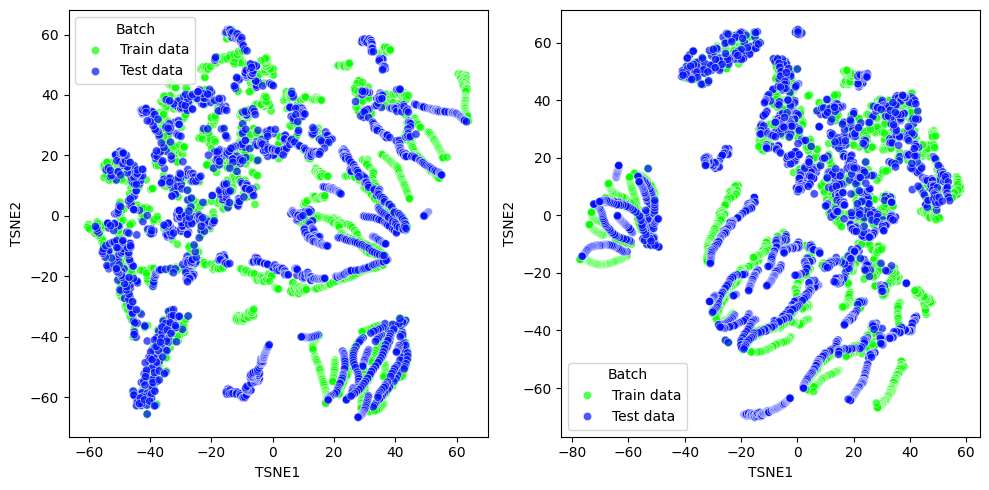

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns



def plot_embeds(agent,train_transitions,test_transitions):

    params = {'params':agent.critic.params}
    params = jax.tree.map(lambda x:x[0],params)
    
    _,train_embeds= OriginalCritic(hidden_dims=(args.hidden_dims,args.hidden_dims)).apply(params,train_transitions["observations"],train_transitions["actions"],mutable='intermediates')
    _,test_embeds= OriginalCritic(hidden_dims=(args.hidden_dims,args.hidden_dims)).apply(params,test_transitions["observations"],test_transitions["actions"],mutable='intermediates')

    train_embeds = train_embeds['intermediates']['features'][0]
    test_embeds = test_embeds['intermediates']['features'][0]


    # Perform t-SNE on both batches
    tsne = TSNE(n_components=2, random_state=0)
  
    tsne_results = tsne.fit_transform(jnp.vstack([train_embeds,test_embeds]))
    # pca = PCA(n_components=2)
    # tsne_results = pca.fit_transform(jnp.vstack([train_embeds,test_embeds]))
    
    tsne_results1,tsne_results2 = tsne_results[:2000],tsne_results[2000:]

    # Create a DataFrame for plotting
    df1 = pd.DataFrame(tsne_results1, columns=['TSNE1', 'TSNE2'])
    df1['Batch'] = 'Train data'
    df2 = pd.DataFrame(tsne_results2, columns=['TSNE1', 'TSNE2'])
    df2['Batch'] = 'Test data'

    # Combine the DataFrames
    df = pd.concat([df1, df2])

    # Plot the results
    #plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='TSNE1', y='TSNE2',
        hue='Batch',
        palette=sns.color_palette("hsv", 2),
        data=df,
        legend="full",
        alpha=0.7
    )
    #plt.title('t-SNE projection of two batches')
    #plt.show()



train_transitions = actor_buffer.get_all()
test_transitions = test_buffer.get_all()



# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Plot in the first subplot
plt.sca(ax1)
plot_embeds(agent_on,train_transitions,test_transitions)


# Plot in the second subplot
plt.sca(ax2)
plot_embeds(agent_off,train_transitions,test_transitions)

# Adjust layout
plt.tight_layout()
plt.show()



In [6]:
dir(tsne)

NameError: name 'tsne' is not defined

In [5]:
jax.config.update('jax_default_matmul_precision', 'highest')
obs = env.reset()

K = np.array(agent.actor.params['means']['kernel'])
noise = jnp.diag(jnp.exp(agent.actor.params['log_stds']))# For state dependant noise but i think formulation is without
K_ref= compute_lqr_feedback_gain(env)

########################################
reference = compute_lqr_V(obs,env,K_ref)
V = compute_lqr_V(obs,env,-K.T)
V_noise = compute_lqr_V_gaussian_policy(obs,env,-K.T,noise)
reference_noise = compute_lqr_V_gaussian_policy(obs,env,K_ref,noise)
print(f'Reference {reference} Reference_noise {reference_noise}')

total = 0
gamma = 1
exploration_rng = jax.random.PRNGKey(52)

print(f'V {V} V_noise {V_noise}')

for i in range(500):

    exploration_rng, key = jax.random.split(exploration_rng)
    action,_,_ = agent.sample_actions(obs,seed=exploration_rng)
    # action = agent.deterministic_action(obs)
    # action = K.T@obs
    next_obs, reward, done, info = env.step(action)  
    obs = next_obs
    total+=gamma*reward
    gamma *= 0.99
    
print(total)


NameError: name 'compute_lqr_feedback_gain' is not defined